# Bölüm 2 — Modelleme: Parametre Adından Kategori Tahmini

**Proje:** GPT Eklenti Ekosisteminde Gizlilik Riski Analizi ve Otomatik Sınıflandırma

**Araştırma Sorusu 3:** Sadece parametre adına (ve varsa açıklamasına) bakarak, o parametrenin hangi kategoriye ait olduğu ne doğrulukla tahmin edilebilir?

**Hedef değişken kararı (Bölüm 1 sonunda verildi):** Ana model `main_data_type` (25, dengeli ve yeterli örneklemli sınıf) üzerine kurulacak — sağlam bir baseline, güvenilir metrikler ve yorumlanabilir feature importance için. Bölüm 2'nin sonunda, aynı pipeline'ı nadir sınıfları gruplayarak `data_type` (145 ince sınıf) üzerinde de deneyeceğiz; bu ikinci deneme Bölüm 3'teki "Other" sınıflandırması (Araştırma Sorusu 5) için de temel oluşturacak.

**Bu bölümün planı:**
1. Problemi kurma: metin özelliği (`name` + `description`) ve hedef (`main_data_type`) tanımlama, train/test ayırma
2. TF-IDF + Lojistik Regresyon (baseline model)
3. Embedding tabanlı model
4. İki modelin karşılaştırılması, feature importance yorumu
5. Aynı pipeline'ın `data_type` (nadir sınıflar gruplanmış) üzerinde denenmesi

## Adım 1 — Problemi Kurma: Girdi/Çıktı Tanımı ve Train/Test Ayrımı

Bir sınıflandırma modeli kurmadan önce iki şeyi netleştirmemiz lazım: **modele ne veriyoruz (X)** ve **modelden ne bekliyoruz (y)**.

- **X (girdi metni):** `name` ve `description`'ı tek bir metinde birleştireceğiz. Bunun sebebi basit: kayıtların %15.6'sında `description` boş (Bölüm 1'de gördük), o zaman modelin elinde sadece `name` kalıyor. İkisini birleştirip tek bir metin sütunu yapmak hem eldeki bilgiyi kaybetmeden kullanmamızı sağlıyor hem de pipeline'ı sadeleştiriyor.
- **y (hedef):** `main_data_type` — 25 sınıf.

Sonra veriyi **train/test** olarak ikiye ayıracağız — modelin daha önce hiç görmediği kayıtlar üzerinde ne kadar başarılı olduğunu ölçebilmek için. Sınıflar dengesiz olduğunu biliyoruz (en büyüğü 2568, en küçüğü 26 kayıt); bu yüzden **stratified split** kullanacağız, yani her sınıfın train ve test kümelerinde yaklaşık aynı oranda temsil edilmesini garanti edeceğiz. Aksi halde küçük bir sınıfın tüm örnekleri şans eseri train'e (ya da test'e) gidebilir ve o sınıf için hiç sağlıklı ölçüm yapamayız.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

X = df['text']
y = df['main_data_type']

print('Toplam kayıt:', len(df))
print('Benzersiz sınıf sayısı:', y.nunique())
df[['name', 'description', 'text', 'main_data_type']].head(3)

Toplam kayıt: 12811
Benzersiz sınıf sayısı: 25


,name,description,text,main_data_type
0,version,The model version,version. The model version,App metadata
1,input,,input.,App usage data
2,prediction_id,,prediction_id.,Identifier


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train boyutu:', X_train.shape[0])
print('Test boyutu:', X_test.shape[0])
print()
print('En küçük sınıfın train/test dağılımı (Weather information):')
print('  train:', (y_train == 'Weather information').sum())
print('  test :', (y_test == 'Weather information').sum())

Train boyutu: 10248
Test boyutu: 2563

En küçük sınıfın train/test dağılımı (Weather information):
  train: 21
  test : 5


## Adım 2 — Baseline Model: TF-IDF + Lojistik Regresyon

**TF-IDF sezgisi:** Bir kelimenin bir kategoriyi ayırt etmede ne kadar işe yaradığını ölçüyoruz. Mantık şu: bir kelime (örn. "password") veri setinin genelinde nadir geçiyor ama geçtiği yerlerde hep aynı kategoriyle (örn. `Security credentials`) birlikte görünüyorsa, bu kelime güçlü bir sinyaldir. Buna karşılık "the", "data", "value" gibi her yerde geçen kelimeler ayırt edici değildir — TF-IDF bu tür kelimelere otomatik olarak düşük ağırlık verir. Sonuçta her metin, hangi kelimelerin ne kadar öne çıktığını gösteren bir sayı listesine (vektöre) dönüşür.

**Neden Lojistik Regresyon ile başlıyoruz:** Hızlı eğitilir, karmaşık değildir ve her kelimenin her kategoriye ne yönde katkı yaptığını (katsayılar üzerinden) doğrudan görebiliriz — bu da ileride "model neye bakarak karar veriyor" sorusunu cevaplarken işimize yarayacak. Asıl amacı karmaşık modellere geçmeden önce **makul bir referans noktası** oluşturmak: embedding tabanlı model bundan daha iyi çıkmazsa, ekstra karmaşıklığa değmez demektir.

TF-IDF'i **sadece train verisiyle** öğreteceğiz (`fit`), test verisine sadece uygulayacağız (`transform`) — aksi halde test setindeki bilgi sızıntısı (data leakage) yaşar, gerçekte olduğundan daha iyi bir sonuç görürüz.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Kelime dağarcığı boyutu:', len(tfidf.vocabulary_))
print('Train matris boyutu:', X_train_tfidf.shape)
print('Test matris boyutu:', X_test_tfidf.shape)

Kelime dağarcığı boyutu: 5000
Train matris boyutu: (10248, 5000)
Test matris boyutu: (2563, 5000)


In [4]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

**Neden hem accuracy hem macro F1'e bakıyoruz:** Sınıflar dengesiz olduğu için sadece accuracy'e bakmak yanıltıcı olabilir — model sadece en büyük sınıfları ("App usage data" gibi) doğru tahmin etse bile accuracy yüksek çıkabilir, küçük sınıflarda tamamen başarısız olsa bile. **Macro F1**, her sınıfı büyüklüğünden bağımsız eşit ağırlıklandırır, bu yüzden nadir sınıflardaki performansı da görünür kılar.

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_macro_baseline = f1_score(y_test, y_pred_baseline, average='macro')
f1_weighted_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f'Accuracy: {acc_baseline:.3f}')
print(f'Macro F1: {f1_macro_baseline:.3f}')
print(f'Weighted F1: {f1_weighted_baseline:.3f}')
print()
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Accuracy: 0.689
Macro F1: 0.468
Weighted F1: 0.692

                                precision    recall  f1-score   support

                  App metadata       1.00      0.36      0.53        28
                App usage data       0.70      0.81      0.75       514
               E-commerce data       0.00      0.00      0.00        13
             Event information       1.00      0.50      0.67        10
           Files and documents       0.67      0.43      0.53        83
           Finance information       1.00      0.14      0.25        28
Food and nutrition information       0.00      0.00      0.00         7
                   Gaming data       0.00      0.00      0.00         5
            Health information       1.00      0.44      0.61        16
                    Identifier       0.85      0.69      0.76       378
Legal and law enforcement data       0.00      0.00      0.00         5
                      Location       0.87      0.76      0.81       140
           

**İlk gözlemler (kesin karşılaştırma embedding modelinden sonra):**
- Accuracy %68.9, macro F1 sadece %46.8 — aradaki fark tam beklediğimiz gibi: model büyük sınıflarda iyi, küçük sınıflarda zayıf.
- Birçok küçük sınıfta precision 1.00 ama recall düşük (örn. `Travel information`: precision 1.00, recall 0.08) — yani model bu sınıfları tahmin ettiğinde haklı çıkıyor, ama çoğu zaman hiç tahmin etmiyor, daha büyük bir sınıfa kayıyor.
- `Other` sınıfı tam tersi bir örüntü gösteriyor: precision 0.36, recall 0.69 — yani model emin olamadığı birçok kaydı "Other" sınıfına atıyor, bu da onu bir tür "çöp kutusu" haline getiriyor. Bu, Bölüm 3'teki "Other" sınıflandırması için önemli bir uyarı işareti.
- Hassas kategorilerden `Security credentials` (F1 0.85) ve `Health information` (F1 0.61) şaşırtıcı derecede iyi ayırt edilebiliyor — muhtemelen "password", "api_key", "symptom" gibi kelimeler çok belirgin sinyaller.

## Adım 3 — Embedding Tabanlı Model

**Sezgi:** TF-IDF sadece *tam kelime örtüşmesine* bakar — "email" ve "e-mail", ya da "password" ve "credential" onun için tamamen alakasız iki kelimedir, çünkü harfleri farklı. Embedding'ler ise kelimeleri **anlamlarına göre** sayısal bir uzayda konumlandırır: anlamca yakın kelimeler bu uzayda birbirine yakın düşer. Bu sayede model, eğitim sırasında hiç görmediği ama anlamca tanıdık bir kelimeyle karşılaştığında da doğru kategoriye yönelebilir — TF-IDF'in yapamayacağı bir şey.

**Bir metodoloji notu:** Normalde burada BERT tabanlı bir `sentence-transformers` modeli tercih ederdik. Ancak bu ortamda Hugging Face'e ağ erişimi organizasyon politikası gereği engellenmiş durumda. Bunun yerine spaCy'nin `en_core_web_md` modelini kullanıyoruz — Common Crawl üzerinde eğitilmiş, GitHub üzerinden indirilebilen 300 boyutlu **GloVe tarzı kelime vektörleri**. Bir metnin embedding'ini, içindeki kelimelerin vektörlerinin ortalamasını alarak elde edeceğiz. Bu, güncel cümle-embedding modelleri kadar güçlü olmasa da, "sparse kelime eşleştirme" (TF-IDF) ile "yoğun anlam temsili" (embedding) arasındaki farkı göstermek için yeterli ve metodolojik olarak dürüst bir karşılaştırma sağlıyor.

**Karşılaştırmayı adil tutmak için:** Sınıflandırıcıyı **aynı** tutuyoruz (Lojistik Regresyon, aynı ayarlarla) — böylece gördüğümüz fark modelden değil, sadece metin temsilinden (TF-IDF vs. embedding) kaynaklanmış olur.

In [6]:
import spacy

try:
    nlp = spacy.load('en_core_web_md', disable=['tagger', 'parser', 'ner', 'lemmatizer'])
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_md'], check=True)
    nlp = spacy.load('en_core_web_md', disable=['tagger', 'parser', 'ner', 'lemmatizer'])

print('Model yüklendi. Vektör boyutu:', nlp.vocab.vectors_length)

Model yüklendi. Vektör boyutu: 300


In [7]:
def texts_to_embeddings(texts, nlp, batch_size=256):
    return np.vstack([doc.vector for doc in nlp.pipe(texts, batch_size=batch_size)])

X_train_emb = texts_to_embeddings(X_train, nlp)
X_test_emb = texts_to_embeddings(X_test, nlp)

print('Train embedding boyutu:', X_train_emb.shape)
print('Test embedding boyutu:', X_test_emb.shape)

Train embedding boyutu: (10248, 300)
Test embedding boyutu: (2563, 300)


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

embedding_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
embedding_model.fit(X_train_emb, y_train)

y_pred_embedding = embedding_model.predict(X_test_emb)

In [9]:
acc_embedding = accuracy_score(y_test, y_pred_embedding)
f1_macro_embedding = f1_score(y_test, y_pred_embedding, average='macro')
f1_weighted_embedding = f1_score(y_test, y_pred_embedding, average='weighted')

print(f'Accuracy: {acc_embedding:.3f}')
print(f'Macro F1: {f1_macro_embedding:.3f}')
print(f'Weighted F1: {f1_weighted_embedding:.3f}')
print()
print(classification_report(y_test, y_pred_embedding, zero_division=0))

Accuracy: 0.549
Macro F1: 0.426
Weighted F1: 0.552

                                precision    recall  f1-score   support

                  App metadata       0.48      0.39      0.43        28
                App usage data       0.56      0.63      0.59       514
               E-commerce data       0.25      0.08      0.12        13
             Event information       0.25      0.30      0.27        10
           Files and documents       0.37      0.29      0.32        83
           Finance information       0.47      0.25      0.33        28
Food and nutrition information       0.25      0.14      0.18         7
                   Gaming data       0.00      0.00      0.00         5
            Health information       0.55      0.69      0.61        16
                    Identifier       0.57      0.56      0.56       378
Legal and law enforcement data       0.00      0.00      0.00         5
                      Location       0.68      0.61      0.64       140
           

**İlk gözlemler:** Embedding tabanlı model, TF-IDF baseline'ının **gerisinde** kaldı (accuracy %54.9 vs %68.9, macro F1 %42.6 vs %46.8). Bu, ilk bakışta "embedding daha zayıfmış" gibi görünse de, aslında verimizin doğasıyla ilgili öğretici bir sonuç: parametre adları çoğunlukla kısa ve çok spesifik teknik terimlerden oluşuyor (`password`, `api_key`, `user_email` gibi). TF-IDF bu tam kelimeleri (ve `ngram_range=(1,2)` sayesinde `api_key` gibi iki kelimelik kalıpları) doğrudan yakalarken, kelime vektörlerinin ortalamasını almak bu keskin sinyali "genel bir anlam bulanıklığına" karıştırıyor. Detaylı karşılaştırmayı ve bunun ne anlama geldiğini bir sonraki adımda ele alacağız.

## Adım 4 — İki Modelin Karşılaştırılması

Genel skorları yan yana koyduktan sonra, asıl ilginç soruya bakacağız: **hangi model hangi kategoride daha iyi?** Genel ortalama tek başına yanıltıcı olabilir — bir model genelde daha iyi olsa bile, belirli kategorilerde diğerinden geride kalabilir. Bunu görmek için her kategori için iki modelin F1 skorlarını karşılaştırıp, farkı tek bir grafikte göstereceğiz (sağa uzayan bar TF-IDF'in daha iyi olduğu, sola uzayan bar embedding'in daha iyi olduğu kategoriler).

In [10]:
comparison = pd.DataFrame({
    'TF-IDF + LogReg': [acc_baseline, f1_macro_baseline, f1_weighted_baseline],
    'Embedding + LogReg': [acc_embedding, f1_macro_embedding, f1_weighted_embedding],
}, index=['Accuracy', 'Macro F1', 'Weighted F1']).round(3)

comparison

,TF-IDF + LogReg,Embedding + LogReg
Accuracy,0.689,0.549
Macro F1,0.468,0.426
Weighted F1,0.692,0.552


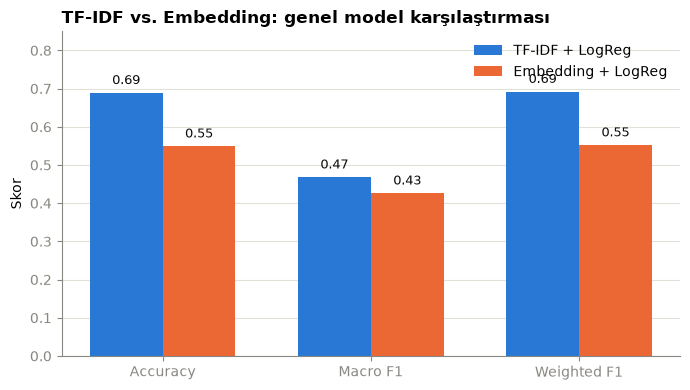

In [11]:
COLOR_TFIDF = '#2a78d6'
COLOR_EMBED = '#eb6834'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

metrics = comparison.index.tolist()
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, comparison['TF-IDF + LogReg'], width, color=COLOR_TFIDF, label='TF-IDF + LogReg')
bars2 = ax.bar(x + width/2, comparison['Embedding + LogReg'], width, color=COLOR_EMBED, label='Embedding + LogReg')

for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9, color=COLOR_TEXT)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Skor')
ax.set_title('TF-IDF vs. Embedding: genel model karşılaştırması', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

In [12]:
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True, zero_division=0)
report_embedding = classification_report(y_test, y_pred_embedding, output_dict=True, zero_division=0)

classes = [c for c in report_baseline.keys() if c not in ('accuracy', 'macro avg', 'weighted avg')]

per_class = pd.DataFrame({
    'f1_tfidf': {c: report_baseline[c]['f1-score'] for c in classes},
    'f1_embedding': {c: report_embedding[c]['f1-score'] for c in classes},
    'support': {c: report_baseline[c]['support'] for c in classes},
})
per_class['diff'] = per_class['f1_tfidf'] - per_class['f1_embedding']
per_class = per_class.sort_values('diff')
per_class.round(3)

,f1_tfidf,f1_embedding,support,diff
Travel information,0.154,0.571,12.0,-0.418
Weather information,0.333,0.571,5.0,-0.238
Real estate data,0.000,0.200,7.0,-0.200
Food and nutrition information,0.000,0.182,7.0,-0.182
E-commerce data,0.000,0.118,13.0,-0.118
Finance information,0.250,0.326,28.0,-0.076
Health information,0.609,0.611,16.0,-0.002
Legal and law enforcement data,0.000,0.000,5.0,0.000
Sports information,0.000,0.000,11.0,0.000
Gaming data,0.000,0.000,5.0,0.000


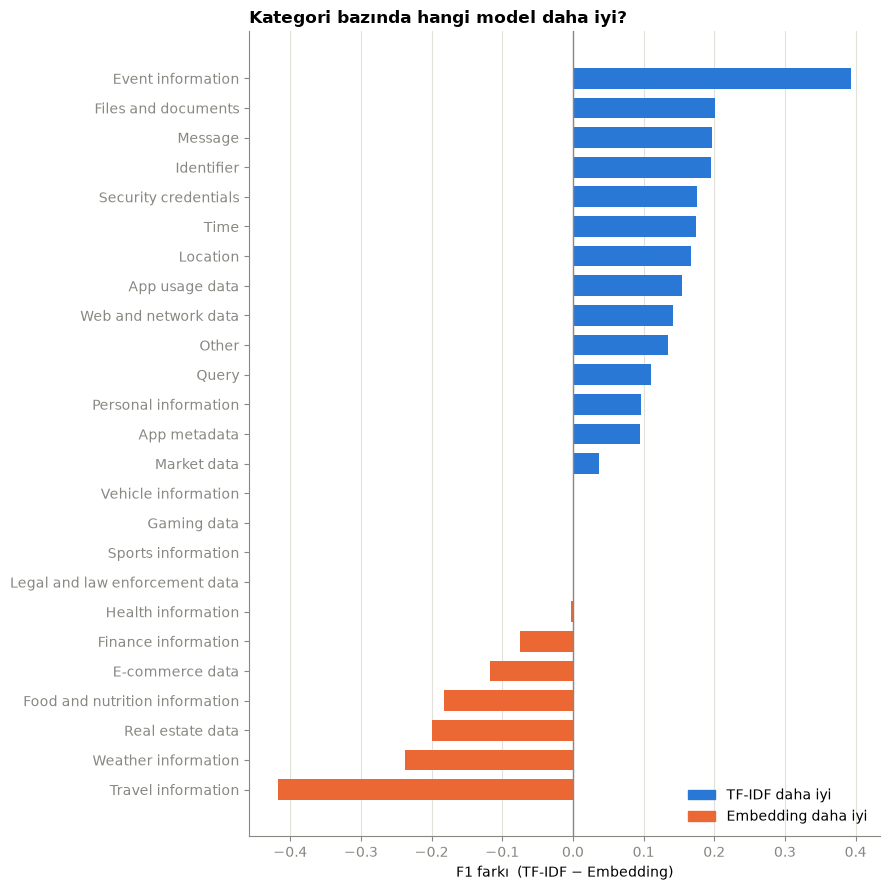

In [13]:
colors_diff = [COLOR_EMBED if d < 0 else COLOR_TFIDF for d in per_class['diff']]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(per_class.index, per_class['diff'], color=colors_diff, height=0.7)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)

ax.set_xlabel('F1 farkı  (TF-IDF − Embedding)')
ax.set_title('Kategori bazında hangi model daha iyi?', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_TFIDF, label='TF-IDF daha iyi'),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_EMBED, label='Embedding daha iyi'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

### Bulgu (model karşılaştırması)

Genel tabloda TF-IDF açıkça önde, ama kategori bazında bakınca ilginç bir ayrım çıkıyor: **embedding modeli tam olarak en nadir sınıflarda** (`Travel information`, `Weather information`, `Real estate data`, `Food and nutrition information`, `E-commerce data`, `Finance information` — hepsi 30'dan az örnek) TF-IDF'i geçiyor. Bunun mantıklı bir açıklaması var: bu sınıflarda o kadar az örnek var ki TF-IDF, o sınıfa özgü ayırt edici kelimeleri güvenilir şekilde öğrenemiyor. Embedding modeli ise önceden eğitilmiş genel dil bilgisini (transfer öğrenme) kullandığı için, hiç görmediği bir kelimeyle karşılaşsa bile anlamca yakın kelimelerden genelleme yapabiliyor.

**Pratik çıkarım:** Tek bir "kazanan" model seçmek yerine, veri miktarı bol olan kategoriler için TF-IDF, çok az örnekli kategoriler için embedding daha güvenilir bir sinyal veriyor gibi görünüyor. Genel performans için TF-IDF baseline'ı tercih ediyoruz (Bölüm 3'e onu taşıyacağız), ama bu gözlemi bir sınırlama olarak not ediyoruz.

## Adım 5 — Feature Importance: Model Neye Bakarak Karar Veriyor?

Lojistik Regresyon, her kelime için her kategoriye ne kadar "oy" verdiğini bir katsayı olarak saklar. Bir kelimenin bir kategori için katsayısı ne kadar büyükse (pozitif), o kelime metinde geçtiğinde model o kategoriye o kadar güçlü yöneliyor demektir. Bu katsayılara bakarak modelin "kafasının içine girebiliriz" — hangi kelimelerin hangi kategoriyi tanımladığını görebiliriz.

Projenin gizlilik odağı gereği özellikle **4 hassas kategoriye** (`Security credentials`, `Personal information`, `Health information`, `Finance information`) odaklanacağız: model bu kategorileri hangi kelimelerden tanıyor? Bu kelimeler makul mü (örn. "password", "ssn"), yoksa model şüpheli/rastgele bir şeye mi tutunmuş — bunu kontrol etmek modele güvenip güvenemeyeceğimiz açısından önemli.

In [14]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_words_for_class(model, class_name, n=10):
    class_idx = list(model.classes_).index(class_name)
    coefs = model.coef_[class_idx]
    top_idx = np.argsort(coefs)[::-1][:n]
    return pd.Series(coefs[top_idx], index=feature_names[top_idx])

SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

for cat in SENSITIVE_CATEGORIES:
    print(f'--- {cat} ---')
    print(top_words_for_class(baseline_model, cat, n=10).round(2).to_string())
    print()

--- Security credentials ---
key            5.39
api_key        4.70
token          4.35
password       4.17
apikey         4.11
api            3.27
secret         3.15
appid          3.15
accesstoken    3.03
api key        2.73

--- Personal information ---
email        5.09
gender       4.08
user         3.44
age          3.09
player       2.91
lastname     2.68
firstname    2.64
birthday     2.51
nickname     2.33
recipient    2.30

--- Health information ---
patient         5.06
does patient    2.96
does            2.57
days            1.66
days patient    1.64
30 days         1.55
30              1.28
dl              1.26
disease         1.12
surgery         0.91

--- Finance information ---
currency             3.62
price                2.45
budget               2.25
related              2.10
unitprice            1.72
asset                1.65
annual               1.59
related filter       1.54
related indicator    1.54
total                1.50



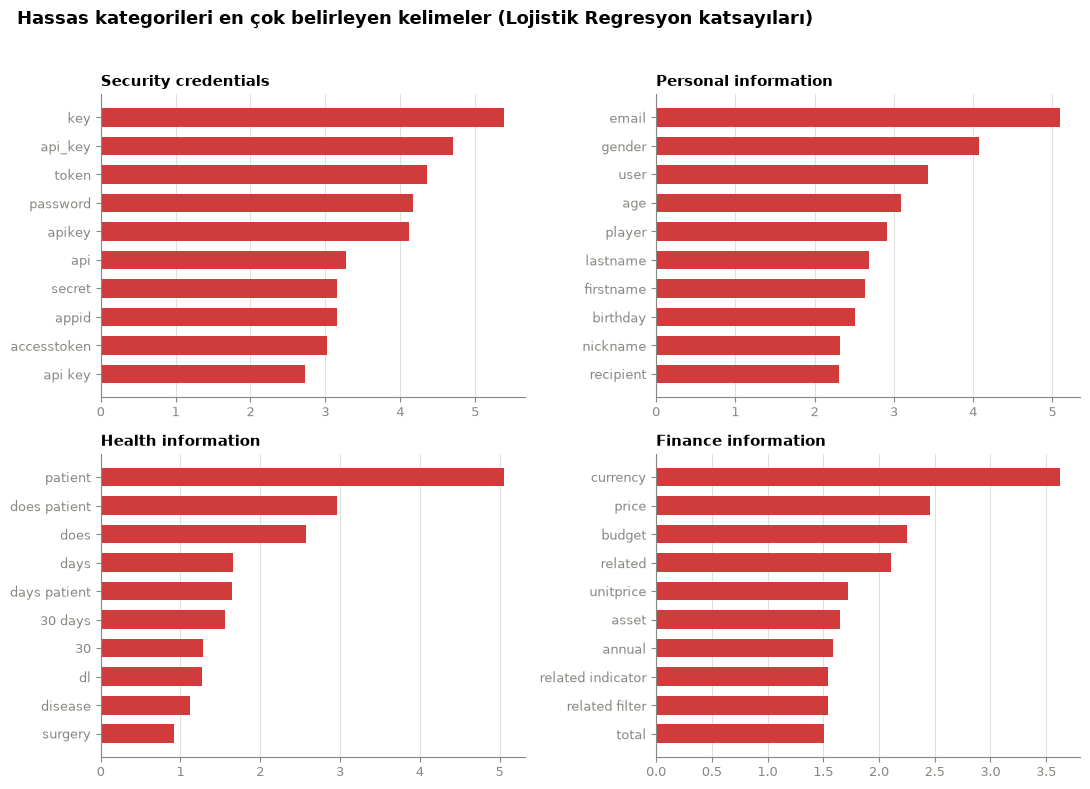

In [15]:
COLOR_SENSITIVE = '#d03b3b'

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, cat in zip(axes.flat, SENSITIVE_CATEGORIES):
    top_words = top_words_for_class(baseline_model, cat, n=10).sort_values()
    ax.barh(top_words.index, top_words.values, color=COLOR_SENSITIVE, height=0.65)
    ax.set_title(cat, loc='left', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)
    ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('Hassas kategorileri en çok belirleyen kelimeler (Lojistik Regresyon katsayıları)',
             x=0.02, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Bulgu (feature importance)

Sonuçlar büyük ölçüde **modele güven veriyor** — kelimeler tesadüfi değil, gerçekten o kategoriyle ilişkili:

- **Security credentials:** `key`, `api_key`, `token`, `password`, `apikey`, `secret` — birebir beklediğimiz kimlik doğrulama terimleri.
- **Personal information:** `email`, `gender`, `age`, `lastname`, `firstname`, `birthday`, `nickname` — klasik PII (kişisel tanımlayıcı bilgi) alanları.
- **Health information:** `patient`, `disease`, `surgery` net sağlık terimleri; ama `does`, `days`, `30 days` gibi kelimeler biraz daha belirsiz — muhtemelen "Does the patient have..." / "how many days..." kalıbındaki sorulardan geliyor, gerçek bir tıbbi sinyalden çok cümle kalıbını yakalıyor.
- **Finance information:** `currency`, `price`, `budget`, `asset`, `annual` mantıklı; ama `related`, `related filter`, `related indicator` gibi ifadeler oldukça genel — muhtemelen "related to finance" gibi tekrar eden bir açıklama kalıbından geliyor, finansal içerikten çok o kalıbı ezberlemiş olabilir.

**Genel çıkarım:** Model çoğunlukla anlamlı, alan-spesifik kelimelere dayanıyor (özellikle Security credentials ve Personal information'da çok güçlü), ama Health ve Finance'ta bazı "kalıp ezberleme" belirtileri var. Bu, modelin tamamen güvenilir olmadığını, özellikle daha az örnekli kategorilerde çıktısının dikkatle yorumlanması gerektiğini gösteriyor.

## Adım 6 — Aynı Pipeline'ı `data_type` (İnce Kategori) Üzerinde Deneme

Şimdiye kadarki her şeyi `main_data_type` (25 sınıf) üzerine kurduk. Ama Bölüm 3'te "Other" kategorisindeki (`data_type` sütununda, 3.544 kayıt) belirsiz kayıtları sınıflandırmak istiyoruz — bunun için bir `data_type` modeline ihtiyacımız var.

**Sorun:** `data_type`'ta 145 farklı değer var ve dağılım aşırı uzun kuyruklu — Bölüm 1'de gördüğümüz gibi medyan sınıf boyutu sadece 11, 6 sınıfta tek bir kayıt bile var. Bu haliyle ne stratified split yapabiliriz ne de bu kadar az örnekli sınıflar için anlamlı bir performans ölçebiliriz.

**Çözüm — nadir sınıfları gruplama:** 10'dan az kaydı olan sınıfları tek bir `"Nadir tür (birleştirilmiş)"` kovasında topluyoruz. Bu, "hangi nadir türün ne olduğunu" tahmin etmekten vazgeçmek anlamına geliyor (zaten bu kadar az veriyle güvenilir tahmin edemezdik), ama geri kalan — yeterince örneklenmiş — sınıflar için sağlam bir model kurmamızı sağlıyor. Eşik değeri olarak 10'u seçtik çünkü stratified split'te her sınıftan test kümesine en az 1-2 örnek düşmesini garanti ediyor.

In [16]:
RARE_THRESHOLD = 10

data_type_counts = df['data_type'].value_counts()
rare_types = data_type_counts[data_type_counts < RARE_THRESHOLD].index

df['data_type_grouped'] = df['data_type'].where(~df['data_type'].isin(rare_types), 'Nadir tür (birleştirilmiş)')

n_rare_classes = len(rare_types)
n_rare_records = df['data_type'].isin(rare_types).sum()

print(f'Orijinal sınıf sayısı: {df["data_type"].nunique()}')
print(f'Gruplama sonrası sınıf sayısı: {df["data_type_grouped"].nunique()}')
print(f'{n_rare_classes} nadir sınıf, toplam {n_rare_records} kayıt (%{n_rare_records/len(df)*100:.1f}) '
      f'"Nadir tür (birleştirilmiş)" kovasında toplandı.')
print()
print('En büyük 10 sınıf (gruplama sonrası):')
print(df['data_type_grouped'].value_counts().head(10))

Orijinal sınıf sayısı: 145
Gruplama sonrası sınıf sayısı: 79
67 nadir sınıf, toplam 285 kayıt (%2.2) "Nadir tür (birleştirilmiş)" kovasında toplandı.

En büyük 10 sınıf (gruplama sonrası):
data_type_grouped
Other                         3544
Current session setting       2171
Resource IDs                   984
Search query                   698
Query filter                   495
Date                           469
URLs                           388
Nadir tür (birleştirilmiş)     285
User identifiers               224
Time period                    221
Name: count, dtype: int64


In [17]:
y_dtype = df['data_type_grouped']

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y_dtype, test_size=0.2, random_state=42, stratify=y_dtype
)

tfidf_dt = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_dt_tfidf = tfidf_dt.fit_transform(X_train_dt)
X_test_dt_tfidf = tfidf_dt.transform(X_test_dt)

model_dt = LogisticRegression(max_iter=1000, random_state=42)
model_dt.fit(X_train_dt_tfidf, y_train_dt)

y_pred_dt = model_dt.predict(X_test_dt_tfidf)

print('Train boyutu:', X_train_dt.shape[0])
print('Test boyutu:', X_test_dt.shape[0])

Train boyutu: 10248
Test boyutu: 2563


In [18]:
acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_macro_dt = f1_score(y_test_dt, y_pred_dt, average='macro')
f1_weighted_dt = f1_score(y_test_dt, y_pred_dt, average='weighted')

print(f'Accuracy: {acc_dt:.3f}')
print(f'Macro F1: {f1_macro_dt:.3f}')
print(f'Weighted F1: {f1_weighted_dt:.3f}')
print(f'(Karşılaştırma: main_data_type modelinde accuracy {acc_baseline:.3f}, macro F1 {f1_macro_baseline:.3f} idi)')

report_dt = classification_report(y_test_dt, y_pred_dt, output_dict=True, zero_division=0)
per_class_dt = pd.DataFrame(report_dt).T.drop(['accuracy', 'macro avg', 'weighted avg'])

print()
print('79 sınıfın F1 skoru dağılımı:')
print(per_class_dt['f1-score'].describe().round(3))
print()
print('Özel ilgi duyduğumuz iki sınıf:')
print(per_class_dt.loc[['Other', 'Nadir tür (birleştirilmiş)']].round(3))

Accuracy: 0.654
Macro F1: 0.359
Weighted F1: 0.627
(Karşılaştırma: main_data_type modelinde accuracy 0.689, macro F1 0.468 idi)

79 sınıfın F1 skoru dağılımı:
count    79.000
mean      0.359
std       0.345
min       0.000
25%       0.000
50%       0.333
75%       0.683
max       0.923
Name: f1-score, dtype: float64

Özel ilgi duyduğumuz iki sınıf:
                            precision  recall  f1-score  support
Other                           0.492   0.872     0.629    709.0
Nadir tür (birleştirilmiş)      0.556   0.175     0.267     57.0


### Bulgu (data_type modeli)

- Accuracy (%65.4) `main_data_type` modeline (%68.9) yakın, ama **macro F1 çok daha düşük** (%35.9 vs %46.8) — beklendiği gibi, 79 sınıfla çalışmak 25 sınıfla çalışmaktan çok daha zor.
- 79 sınıfın F1 dağılımına bakınca çarpıcı bir şey görüyoruz: **alt çeyrek (25. persentil) tam olarak 0** — yani sınıfların dörtte biri kadarında model tamamen başarısız (hiç doğru tahmin edememiş). Bu, ince kategorilere inildikçe modelin güvenilirliğinin ciddi şekilde azaldığını gösteriyor.
- `Other` sınıfı yine tanıdık örüntüsünü tekrarlıyor: precision 0.49, recall 0.87 — model kararsız kaldığında hâlâ "Other"a kaçıyor. Bu, Bölüm 3'te "Other" kayıtlarını başka bir kategoriye atamaya çalışırken **dikkatli olmamız gerektiği** anlamına geliyor — model "Other" etiketini çok kolay veriyor, ama bu her zaman doğru bir tahmin olduğu anlamına gelmiyor.
- `Nadir tür (birleştirilmiş)` kovası düşük performans gösteriyor (F1 0.27) — beklenen bir sonuç, çünkü bu kova birbiriyle alakasız 67 farklı türü bir araya getiriyor; ortak bir kelime dağarcığı yok.

**Bölüm 2 sonucu:** `main_data_type` üzerinde sağlam bir baseline kurduk (TF-IDF + LogReg, accuracy %68.9). `data_type` üzerinde ince kategoriye inmek mümkün ama ciddi güven kaybıyla geliyor. Bölüm 3'te "Other" kayıtlarını sınıflandırırken bu modeli kullanacağız, ama tahminleri mutlak doğru kabul etmek yerine bir öneri/hipotez olarak ele alacağız.